In [1]:
import os
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

os.makedirs("outputs/tables", exist_ok=True)
os.makedirs("outputs/figures", exist_ok=True)

In [2]:
df = pd.read_csv("GEFCom2014_prepared.csv")

df["date"] = pd.to_datetime(df["date"])

df = df.sort_values(["date", "hour"]).reset_index(drop=True)

In [3]:


df["hour"] = df["hour"].astype(int) % 24
df["day_of_week"] = df["day_of_week"].astype(int) % 7
df["month"] = df["month"].astype(int) - 1   # 0–11
df["is_weekend"] = df["is_weekend"].astype(int)

if "sum_zones" in df.columns:
    df = df.drop(columns=["sum_zones"])

In [4]:
load_features = ['load', 'lag_1', 'lag_24', 'load_roll_mean_24', 'load_roll_std_24']

temp_features = [
    'temp', 'temp_lag_1', 'temp_lag_24',
    'temp_roll_mean_24', 'temp_roll_std_24',
    'CDD', 'HDD'
]

calendar_features = ['hour', 'day_of_week', 'month', 'is_weekend']

zone_cols = [
    "zone_residential",
    "zone_commercial",
    "zone_industrial"
]

df["total_zone_load"] = (
    df["zone_residential"] +
    df["zone_commercial"] +
    df["zone_industrial"]
)

print("Zones:", zone_cols)

Zones: ['zone_residential', 'zone_commercial', 'zone_industrial']


In [5]:
# ==========================================
# TRAIN-TEST SPLIT BEFORE NORMALIZATION
# ==========================================

split_idx = int(0.8 * len(df))

train_df = df.iloc[:split_idx].copy()
test_df = df.iloc[split_idx:].copy()

# ==========================================
# NORMALIZATION
# ==========================================

scaler = MinMaxScaler()

scale_cols = (
    load_features +
    temp_features +
    zone_cols +
    ["total_zone_load"]
)

# FIT ONLY ON TRAIN DATA
train_df[scale_cols] = scaler.fit_transform(
    train_df[scale_cols]
)

# TRANSFORM TEST USING TRAIN STATISTICS
test_df[scale_cols] = scaler.transform(
    test_df[scale_cols]
)

In [6]:
SEQ_LEN = 24

class MultiModalDataset(Dataset):
    def __init__(self, df):
        self.load_data = df[load_features].values.astype(np.float32)
        self.temp_data = df[temp_features].values.astype(np.float32)
        self.cal_data = df[calendar_features].values.astype(np.int64)
        self.targets = df[zone_cols].values.astype(np.float32)

    def __len__(self):
        return len(self.load_data) - SEQ_LEN

    def __getitem__(self, idx):
        Xl = self.load_data[idx:idx+SEQ_LEN]
        Xt = self.temp_data[idx:idx+SEQ_LEN]
        Xc = self.cal_data[idx:idx+SEQ_LEN]

        y = self.targets[idx+SEQ_LEN]

        return (
            torch.tensor(Xl),
            torch.tensor(Xt),
            torch.tensor(Xc),
            torch.tensor(y)
        )

In [7]:
train_ds = MultiModalDataset(train_df)

test_ds = MultiModalDataset(test_df)

train_loader = DataLoader(
    train_ds,
    batch_size=64,
    shuffle=False
)

test_loader = DataLoader(
    test_ds,
    batch_size=64,
    shuffle=False
)

In [8]:
class MultimodalMultiZoneModel(nn.Module):
    def __init__(self, num_zones):
        super().__init__()

        # Load encoder
        self.lstm = nn.LSTM(
            input_size=len(load_features),
            hidden_size=64,
            batch_first=True
        )

        # Temp encoder
        self.temp_mlp = nn.Sequential(
            nn.Linear(len(temp_features), 64),
            nn.ReLU(),
            nn.Linear(64, 32)
        )

        # Calendar embeddings
        self.hour_emb = nn.Embedding(24, 8)
        self.day_emb = nn.Embedding(7, 4)
        self.month_emb = nn.Embedding(12, 4)
        self.weekend_emb = nn.Embedding(2, 2)

        fusion_size = 64 + 32 + (8 + 4 + 4 + 2)

        # 🔥 Multi-zone output
        self.fc = nn.Sequential(
            nn.Linear(fusion_size, 64),
            nn.ReLU(),
            nn.Linear(64, num_zones)
        )

    def forward(self, Xl, Xt, Xc):

        _, (h, _) = self.lstm(Xl)
        load_out = h[-1]

        temp_out = self.temp_mlp(Xt[:, -1, :])

        hour = self.hour_emb(Xc[:, -1, 0])
        day = self.day_emb(Xc[:, -1, 1])
        month = self.month_emb(Xc[:, -1, 2])
        weekend = self.weekend_emb(Xc[:, -1, 3])

        cal_out = torch.cat([hour, day, month, weekend], dim=1)

        fused = torch.cat([load_out, temp_out, cal_out], dim=1)

        return self.fc(fused)

In [9]:
model = MultimodalMultiZoneModel(num_zones=len(zone_cols)).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [10]:
EPOCHS = 20

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    for Xl, Xt, Xc, y in train_loader:
        Xl, Xt, Xc, y = Xl.to(device), Xt.to(device), Xc.to(device), y.to(device)

        optimizer.zero_grad()
        preds = model(Xl, Xt, Xc)

        loss = criterion(preds, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1} | Loss: {total_loss:.4f}")

Epoch 1 | Loss: 9.7410
Epoch 2 | Loss: 2.4965
Epoch 3 | Loss: 1.3913
Epoch 4 | Loss: 1.3870
Epoch 5 | Loss: 1.2967
Epoch 6 | Loss: 1.1950
Epoch 7 | Loss: 1.1347
Epoch 8 | Loss: 1.0618
Epoch 9 | Loss: 1.0113
Epoch 10 | Loss: 0.9528
Epoch 11 | Loss: 0.9196
Epoch 12 | Loss: 0.8805
Epoch 13 | Loss: 0.8668
Epoch 14 | Loss: 0.8471
Epoch 15 | Loss: 0.8397
Epoch 16 | Loss: 0.7936
Epoch 17 | Loss: 0.8291
Epoch 18 | Loss: 0.7115
Epoch 19 | Loss: 0.8177
Epoch 20 | Loss: 0.7451


In [11]:
model.eval()

all_preds = []
all_true = []

with torch.no_grad():
    for Xl, Xt, Xc, y in test_loader:
        Xl, Xt, Xc = Xl.to(device), Xt.to(device), Xc.to(device)

        preds = model(Xl, Xt, Xc).cpu().numpy()

        all_preds.append(preds)
        all_true.append(y.numpy())

all_preds = np.vstack(all_preds)
all_true = np.vstack(all_true)

pred_total = all_preds.sum(axis=1, keepdims=True)
true_total = all_true.sum(axis=1, keepdims=True)

# Full hierarchy:
# [Residential, Commercial, Industrial, Total]

preds_full = np.concatenate(
    [all_preds, pred_total],
    axis=1
)

true_full = np.concatenate(
    [all_true, true_total],
    axis=1
)

# ==========================================
# OLS RECONCILIATION
# ==========================================

def ols_reconciliation(zone_preds):

    n = zone_preds.shape[1]

    # Summation matrix
    S = np.vstack([

        np.eye(n),

        np.ones((1, n))

    ])

    # Base forecasts
    base_total = zone_preds.sum(
        axis=1,
        keepdims=True
    )

    base_forecasts = np.concatenate(

        [zone_preds, base_total],

        axis=1

    )

    # OLS reconciliation
    G = np.linalg.inv(
        S.T @ S
    ) @ S.T

    reconciled = (

        S @ G @ base_forecasts.T

    ).T

    return reconciled

In [12]:
ind_preds = preds_full

ols_preds = ols_reconciliation(
    all_preds
)

In [13]:
def evaluate(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return mae, rmse

def coherence_error(preds):
    # Check if sum of zones (0,1,2) equals the total (3)
    return np.mean(np.abs(preds[:, :3].sum(axis=1) - preds[:, 3]))

# These will now run without ValueError
mae_ind, rmse_ind = evaluate(true_full, ind_preds)

coh_ind = coherence_error(ind_preds)

mae_ols, rmse_ols = evaluate(
    true_full,
    ols_preds
)

coh_ols = coherence_error(
    ols_preds
)

In [14]:
results = pd.DataFrame({

    "Model": ["Independent", "OLS"],

    "MAE": [
        mae_ind,
        mae_ols
    ],

    "RMSE": [
        rmse_ind,
        rmse_ols
    ],

    "Coherence Error": [
        coh_ind,
        coh_ols
    ]

})

results.to_csv("outputs/tables/rq2_coherence_results.csv", index=False)

results

,Model,MAE,RMSE,Coherence Error
0,Independent,0.030574,0.040283,0.000000e+00
1,OLS,0.030574,0.040283,7.170249e-19


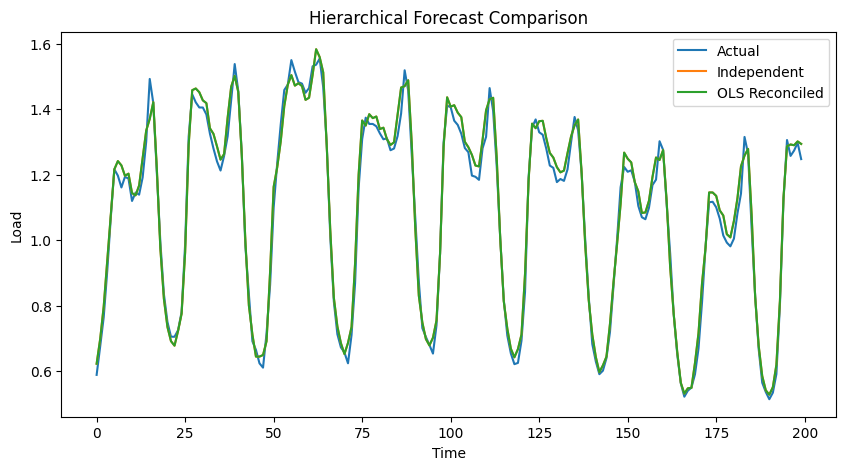

In [15]:
plt.figure(figsize=(10,5))

plt.plot(
    true_full[:200, -1],
    label="Actual"
)

plt.plot(
    ind_preds[:200, -1],
    label="Independent"
)

plt.plot(
    ols_preds[:200, -1],
    label="OLS Reconciled"
)

plt.legend()

plt.title(
    "Hierarchical Forecast Comparison"
)

plt.xlabel("Time")
plt.ylabel("Load")

plt.savefig(
    "outputs/figures/rq2_hierarchical_comparison.pdf"
)

plt.show()

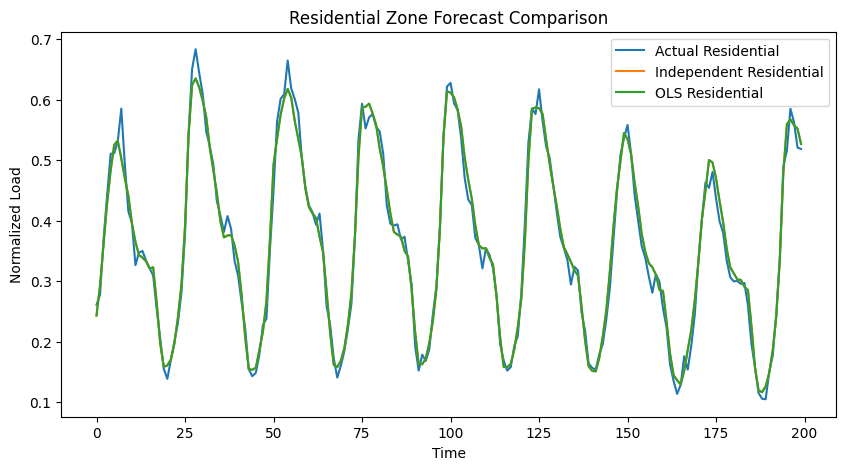

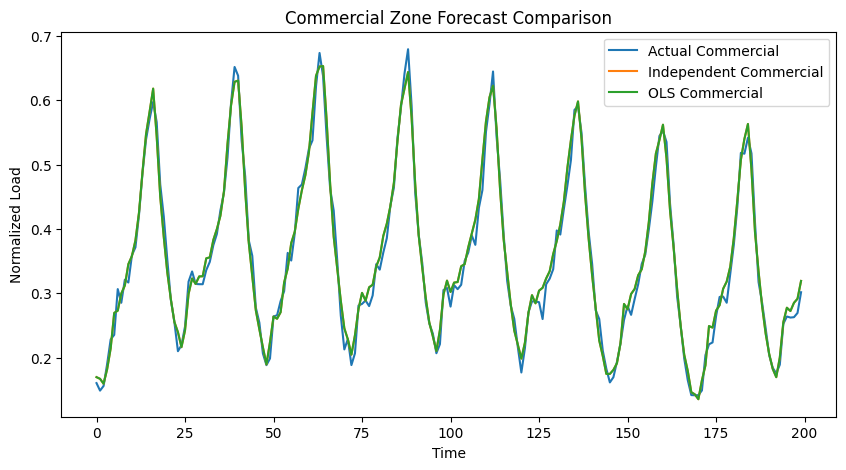

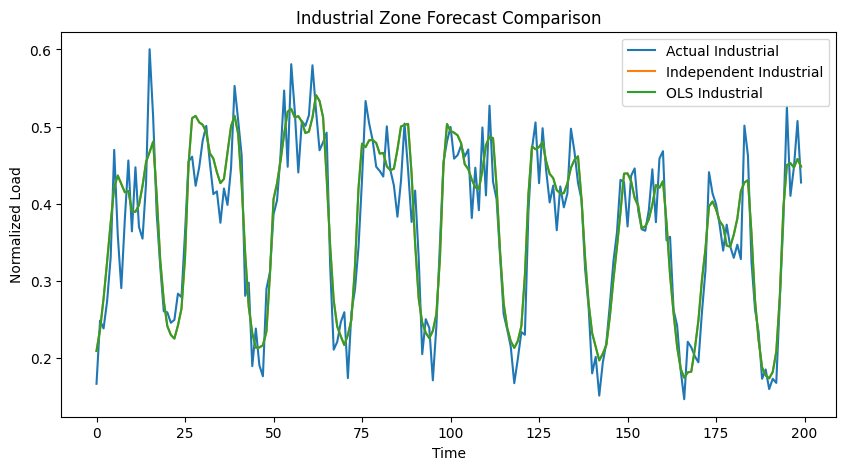

In [16]:
# ==========================================
# ZONE-WISE FORECAST PLOTS
# ==========================================

zone_names = [
    "Residential",
    "Commercial",
    "Industrial"
]

for i, zone in enumerate(zone_names):

    plt.figure(figsize=(10,5))

    # Actual values
    plt.plot(
        true_full[:200, i],
        label=f"Actual {zone}"
    )

    # Independent forecasts
    plt.plot(
        ind_preds[:200, i],
        label=f"Independent {zone}"
    )

    # OLS forecasts
    plt.plot(
        ols_preds[:200, i],
        label=f"OLS {zone}"
    )

    plt.legend()

    plt.title(
        f"{zone} Zone Forecast Comparison"
    )

    plt.xlabel("Time")
    plt.ylabel("Normalized Load")

    plt.savefig(
        f"outputs/figures/rq2_{zone.lower()}_comparison.pdf"
    )

    plt.show()